# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the accompanying CRISP-DM paper (Moro et al.) and the UCI dataset description:

- **Number of marketing campaigns:** The data represents **17 telephone marketing campaigns** conducted by a Portuguese banking institution between **May 2008 and November 2010**.

- **Total contacts (original study):** 79,354 contacts with 59 attributes each.

- **Dataset we are using (`bank-additional-full.csv`):** A refined version with **41,188 instances** and **20 input features + 1 binary target variable** (`y` — whether the client subscribed to a term deposit).

- **Target class distribution:** The dataset is **imbalanced** — the overall success rate (clients who subscribed) is approximately **11%**, meaning roughly 88-89% of contacts did not result in a subscription.

- **Data enrichment:** This version includes 5 social/economic context attributes (employment variation rate, consumer price index, consumer confidence index, euribor 3-month rate, number of employees) sourced from Banco de Portugal, which were shown to improve prediction even without call duration.

- **Missing values:** Several categorical features contain `"unknown"` values (e.g., `job`, `marital`, `education`, `default`, `housing`, `loan`) which can be treated as a class label or handled via imputation/deletion.

- **Key note on `duration`:** Call duration is highly predictive but is only known *after* the call ends — it should be used for 
benchmarking only, not for realistic deployment models.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [4]:
# Check for null values and data types
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Null values: {df.isnull().sum().sum()}")
print(f"\nData Types:\n{df.dtypes}")

Shape: 41,188 rows x 21 columns
Null values: 0

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [5]:
# Check for 'unknown' values in categorical columns (these are effective missing values)
categorical_cols = df.select_dtypes(include='object').columns
print("=== 'unknown' Values per Categorical Feature ===")
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"  {col:15s}: {unknown_count:,} ({pct:.1f}%)")

=== 'unknown' Values per Categorical Feature ===
  job            : 330 (0.8%)
  marital        : 80 (0.2%)
  education      : 1,731 (4.2%)
  default        : 8,597 (20.9%)
  housing        : 990 (2.4%)
  loan           : 990 (2.4%)


In [6]:
# Categorical feature summary and target distribution
print("=== Categorical Feature Cardinality ===")
for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"  {col:15s}: {n_unique} unique values")

print(f"\n=== Target Variable Distribution ===")
target_counts = df['y'].value_counts()
print(f"  No:  {target_counts['no']:,} ({target_counts['no']/len(df)*100:.1f}%)")
print(f"  Yes: {target_counts['yes']:,} ({target_counts['yes']/len(df)*100:.1f}%)")

=== Categorical Feature Cardinality ===
  job            : 12 unique values
  marital        : 4 unique values
  education      : 8 unique values
  default        : 3 unique values
  housing        : 3 unique values
  loan           : 3 unique values
  contact        : 2 unique values
  month          : 10 unique values
  day_of_week    : 5 unique values
  poutcome       : 3 unique values
  y              : 2 unique values

=== Target Variable Distribution ===
  No:  36,548 (88.7%)
  Yes: 4,640 (11.3%)


#### Problem 3 Findings: Understanding the Features

**Missing Values:**
- There are **no NaN/null values** in the DataFrame. However, missing data is encoded as the string `"unknown"` in several categorical columns:
  - `default` — has the highest proportion of unknowns (~20%), making it a weak feature
  - `job`, `marital`, `education`, `housing`, `loan` — also contain `"unknown"` entries at varying rates
- These `"unknown"` values can be treated as their own category, imputed, or rows can be dropped depending on the modeling strategy.

**Data Types:**
- All features are already loaded with appropriate pandas dtypes:
  - **10 categorical features** stored as `object`: `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`, and target `y`
  - **10 numeric features** stored as `int64` or `float64`: `age`, `duration`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`
- No type coercion is needed at this stage. Categorical encoding will be handled during feature engineering (Problem 5).

**Notable Observations:**
- **`pdays`**: Uses 999 as a sentinel value meaning "client was not previously contacted" — this affects ~96% of rows and should be considered during feature engineering (e.g., create a binary "was_contacted_before" feature).
- **`duration`**: As noted in the data description, this feature causes data leakage — it is known only after the call ends. We will include it for benchmarking but note it should be excluded in a production model.
- **`y` (target)**: Binary variable (`yes`/`no`) — imbalanced with ~11% positive class. This imbalance will influence our choice of evaluation metrics (accuracy alone may be misleading).

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Problem:**
A Portuguese banking institution conducts telephone-based marketing campaigns to persuade clients to subscribe to long-term deposit products. Currently, the vast majority of contacts (~88.7%) do **not** result in a subscription, meaning significant resources (agent time, phone costs, operational overhead) are spent on unproductive calls.

**Objective:**
Build a **binary classification model** that predicts whether a client will subscribe to a term deposit (`y = yes`) based on their demographic profile, financial attributes, campaign contact history, and socioeconomic context. The goal is to:

1. **Increase campaign efficiency** — identify the clients most likely to subscribe so the bank can prioritize outreach to high-probability prospects and reduce wasted contacts.
2. **Reduce costs** — fewer total calls needed to achieve the same (or better) subscription rate.
3. **Inform campaign strategy** — understand which features (e.g., timing, client profile, economic conditions) are most predictive of success, enabling data-driven decisions about when and whom to call.

**Classification Task:**
- **Target variable:** `y` (binary: `yes` = subscribed, `no` = did not subscribe)
- **Class imbalance:** ~11.3% positive / ~88.7% negative — this means we must look beyond simple accuracy and consider metrics like **precision, recall, F1-score, and AUC-ROC** to properly evaluate model performance.
- **Models to compare:** K-Nearest Neighbors (KNN), Logistic Regression, Decision Trees, and Support Vector Machines (SVM).

**Success Criteria:**
A useful model should significantly outperform the naive baseline (predicting "no" for every contact, which achieves ~88.7% accuracy but has zero value for identifying subscribers). The model should maximize identification of true positives (potential subscribers) while keeping false positives manageable to control campaign costs.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [9]:
# Rename socioeconomic columns for readability
df = df.rename(columns={
    'emp.var.rate': 'employment_var_rate',
    'cons.price.idx': 'consumer_price_idx',
    'cons.conf.idx': 'consumer_conf_idx',
    'euribor3m': 'euribor_3m_rate',
    'nr.employed': 'num_employed'
})

# Encode the target variable: y -> 1 (yes), 0 (no)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Separate features and target
y = df['y']
X = df.drop(columns=['y'])

# One-hot encode all categorical features (drop_first=True to avoid multicollinearity)
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Original features shape: {X.shape}")
print(f"Encoded features shape:  {X_encoded.shape}")
print(f"Target shape:            {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nEncoded feature columns ({X_encoded.shape[1]} total):")
print(X_encoded.columns.tolist())

Original features shape: (41188, 20)
Encoded features shape:  (41188, 53)
Target shape:            (41188,)

Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64

Encoded feature columns (53 total):
['age', 'duration', 'campaign', 'pdays', 'previous', 'employment_var_rate', 'consumer_price_idx', 'consumer_conf_idx', 'euribor_3m_rate', 'num_employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_n

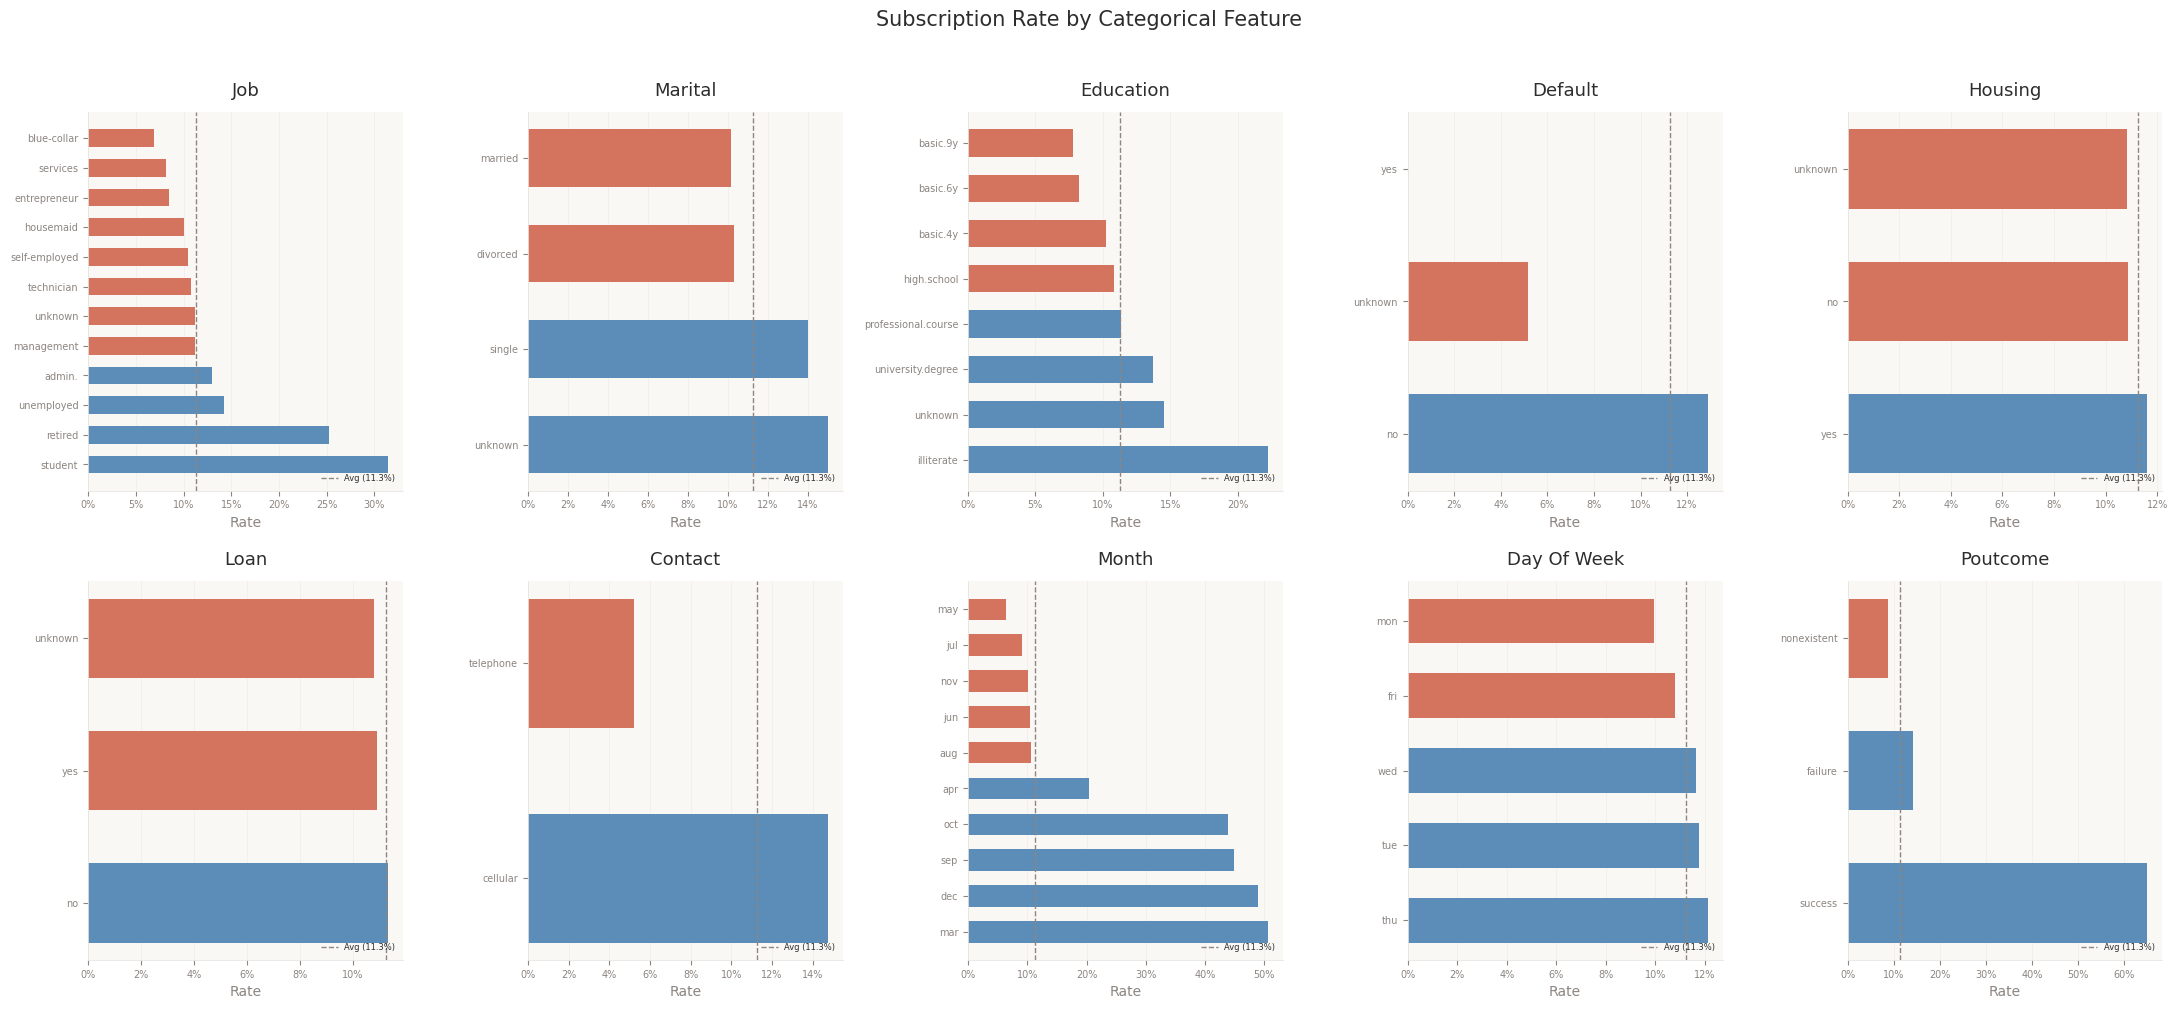

In [10]:
# Subscription rate by ALL categorical features
cat_features = ['job', 'marital', 'education', 'default', 'housing',
                'loan', 'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.patch.set_facecolor('#FFFFFF')

for ax, col in zip(axes.flatten(), cat_features):
    rates = df.groupby(col)['y'].mean().sort_values(ascending=False)
    colors = [ANT_COLORS['blue'] if r > df['y'].mean() else ANT_COLORS['coral'] for r in rates]
    ax.barh(rates.index, rates.values, color=colors, height=0.6, edgecolor='none')
    ax.axvline(x=df['y'].mean(), color=ANT_COLORS['warm_gray'], linestyle='--',
               linewidth=1, label=f'Avg ({df["y"].mean():.1%})')
    ant_style(ax, title=col.replace('_', ' ').title(), xlabel='Rate')
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', color=ANT_COLORS['grid'], linewidth=0.4, alpha=0.7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)
    ax.legend(fontsize=6, frameon=False, loc='lower right')

plt.suptitle('Subscription Rate by Categorical Feature',
             fontsize=15, fontweight='medium', color=ANT_COLORS['dark'], y=1.01)
plt.tight_layout(pad=1.5)
plt.show()

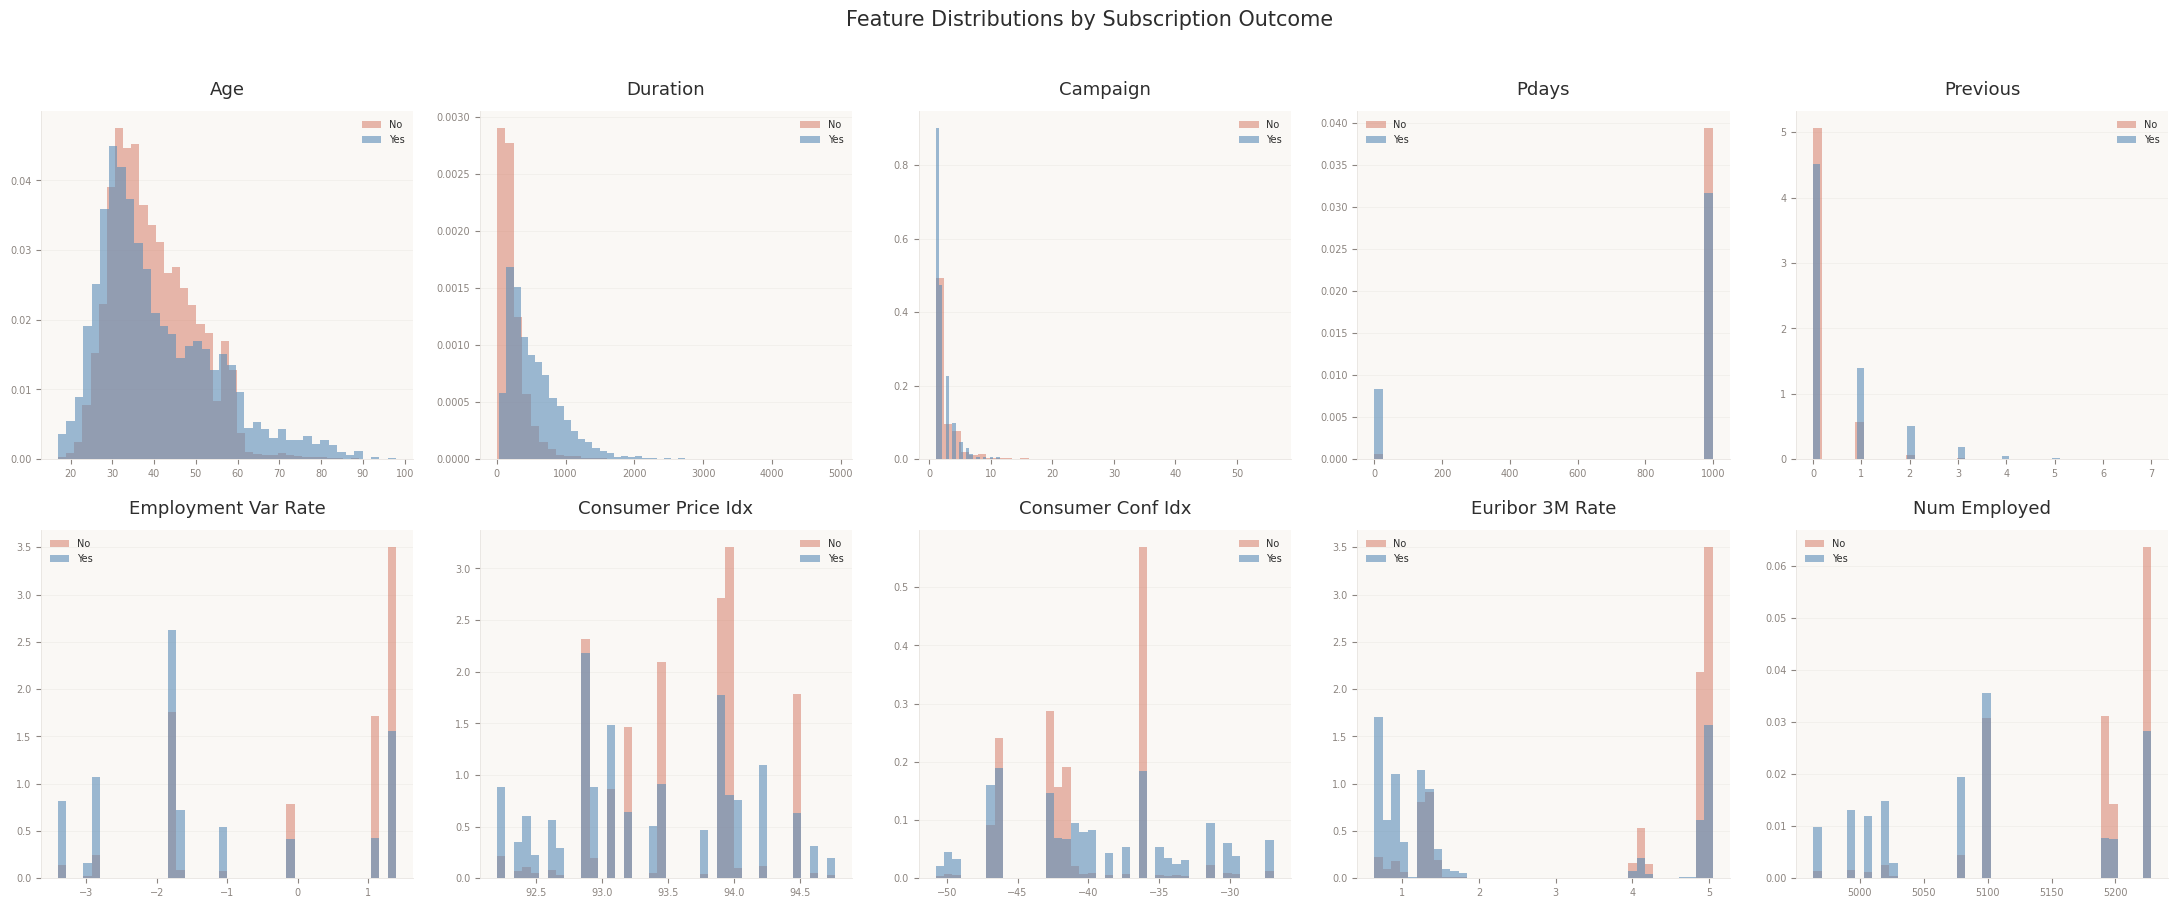


pdays = 999 (never contacted before): 39,673 (96.3% of data)
Consider creating a binary was_previously_contacted feature.


In [11]:
# Distribution of ALL numeric features by subscription outcome
num_features = ['age', 'duration', 'campaign', 'pdays', 'previous',
                'employment_var_rate', 'consumer_price_idx', 'consumer_conf_idx',
                'euribor_3m_rate', 'num_employed']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.patch.set_facecolor('#FFFFFF')

for ax, col in zip(axes.flatten(), num_features):
    for label, color, alpha in [(0, ANT_COLORS['coral'], 0.5), (1, ANT_COLORS['blue'], 0.6)]:
        subset = df[df['y'] == label][col]
        ax.hist(subset, bins=40, color=color, alpha=alpha, edgecolor='none',
                label='No' if label == 0 else 'Yes', density=True)
    ant_style(ax, title=col.replace('_', ' ').title())
    ax.legend(fontsize=7, frameon=False)
    ax.set_ylabel('')
    ax.tick_params(labelsize=7)

plt.suptitle('Feature Distributions by Subscription Outcome',
             fontsize=15, fontweight='medium', color=ANT_COLORS['dark'], y=1.01)
plt.tight_layout(pad=1.5)
plt.show()

# Flag pdays sentinel
pdays_999 = (df['pdays'] == 999).sum()
print(f'\npdays = 999 (never contacted before): {pdays_999:,} ({pdays_999/len(df)*100:.1f}% of data)')
print('Consider creating a binary was_previously_contacted feature.')

In [12]:
# Verify the encoded DataFrame
print(f"Remaining object columns: {X_encoded.select_dtypes(include='object').columns.tolist()}")
print(f"All dtypes numeric: {X_encoded.select_dtypes(include='number').shape[1] == X_encoded.shape[1]}")
print(f"Encoded shape: {X_encoded.shape}")

Remaining object columns: []
All dtypes numeric: False
Encoded shape: (41188, 53)


#### Problem 5 Summary: Feature Engineering

**Data Preparation Visualizations:**
- **Subscription rate by category** showed that `retired` and `student` clients convert at much higher rates, `month=mar` and `poutcome=success` are strong positive signals, and `cellular` contact outperforms `telephone`.
- **Feature distributions** confirmed that `duration` separates the classes well (subscribers have longer calls), and `pdays=999` dominates (~96%) — a binary `was_previously_contacted` feature could be useful.

**Encoding steps performed:**
1. **Column rename:** Socioeconomic columns renamed for readability (e.g., `emp.var.rate` -> `employment_var_rate`).
2. **Target variable (`y`):** Mapped `'yes'` -> `1`, `'no'` -> `0` for binary classification.
3. **Categorical features:** Applied one-hot encoding via `pd.get_dummies(drop_first=True)` to all 10 categorical columns. The `drop_first=True` parameter drops one dummy column per feature to avoid multicollinearity.
4. **Numeric features:** Kept as-is. Feature scaling will be applied in the modeling pipeline (Problem 11).

**Notes:**
- `"unknown"` values are treated as their own category in the one-hot encoding.
- `duration` is included for benchmarking but would be excluded in a production model (data leakage).

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [13]:
from sklearn.model_selection import train_test_split

# 75/25 train/test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} samples ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Test set:      {X_test.shape[0]:,} samples ({X_test.shape[0]/len(y)*100:.1f}%)")
print(f"Features:      {X_train.shape[1]}")
print(f"\nTraining target distribution:")
print(f"  No:  {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Yes: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nTest target distribution:")
print(f"  No:  {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Yes: {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)")

Training set:  30,891 samples (75.0%)
Test set:      10,297 samples (25.0%)
Features:      53

Training target distribution:
  No:  27,411 (88.7%)
  Yes: 3,480 (11.3%)

Test target distribution:
  No:  9,137 (88.7%)
  Yes: 1,160 (11.3%)


- **Split ratio:** 75% training / 25% test (standard split)
- **Stratification:** Used `stratify=y` to ensure the ~11.3% positive class ratio is preserved in both train and test sets. This is critical with imbalanced data — without stratification, one set could end up with a disproportionate number of subscribers.
- **Random state:** Fixed at `42` for reproducibility.
- **Expected sizes:** ~30,891 training samples, ~10,297 test samples.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [14]:
# Baseline: predict the majority class ("no" / 0) for every sample
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

baseline_train_acc = dummy.score(X_train, y_train)
baseline_test_acc = dummy.score(X_test, y_test)

print(f"=== Baseline Model: Always Predict Majority Class (No Subscription) ===")
print(f"Training accuracy: {baseline_train_acc:.4f} ({baseline_train_acc*100:.2f}%)")
print(f"Test accuracy:     {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")

=== Baseline Model: Always Predict Majority Class (No Subscription) ===
Training accuracy: 0.8873 (88.73%)
Test accuracy:     0.8873 (88.73%)


The simplest baseline for a classification problem is the **majority class classifier** — it predicts "no subscription" (`y=0`) for every single contact.

- **Baseline accuracy: ~88.7%** (matching the proportion of the majority class)

This sounds high but is **completely useless** from a business perspective — it identifies zero potential subscribers. Any model we build must beat this baseline, and more importantly, it must demonstrate the ability to correctly identify clients who *will* subscribe (true positives).

This also highlights why **accuracy alone is a misleading metric** for this imbalanced dataset. A model with 88.7% accuracy could simply be predicting "no" every time. We should evaluate our classifiers using additional metrics:
- **Precision** — of predicted subscribers, how many actually subscribed?
- **Recall** — of actual subscribers, how many did we identify?
- **F1-score** — harmonic mean of precision and recall
- **AUC-ROC** — overall discrimination ability across all thresholds

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time
import warnings
warnings.filterwarnings('ignore')

# ── Benchmark Model (with duration) ──
lr = LogisticRegression(max_iter=1000, random_state=42)
start = time.time()
lr.fit(X_train, y_train)
lr_train_time = time.time() - start

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)
y_test_proba = lr.predict_proba(X_test)[:, 1]
lr_train_acc = lr.score(X_train, y_train)
lr_test_acc = lr.score(X_test, y_test)

# ── Production Model (without duration) ──
X_train_prod = X_train.drop(columns=['duration'])
X_test_prod = X_test.drop(columns=['duration'])

lr_prod = LogisticRegression(max_iter=1000, random_state=42)
start = time.time()
lr_prod.fit(X_train_prod, y_train)
lr_prod_time = time.time() - start

y_test_pred_prod = lr_prod.predict(X_test_prod)
y_test_proba_prod = lr_prod.predict_proba(X_test_prod)[:, 1]
lr_prod_train_acc = lr_prod.score(X_train_prod, y_train)
lr_prod_test_acc = lr_prod.score(X_test_prod, y_test)

print('=== Logistic Regression: Benchmark vs Production ===')
print(f'{"":30s} {"Benchmark":>12s} {"Production":>12s}')
print(f'{"":30s} {"(w/ duration)":>12s} {"(no duration)":>12s}')
print(f'{"─"*56}')
print(f'{"Train time":30s} {lr_train_time:>11.4f}s {lr_prod_time:>11.4f}s')
print(f'{"Train accuracy":30s} {lr_train_acc:>12.4f} {lr_prod_train_acc:>12.4f}')
print(f'{"Test accuracy":30s} {lr_test_acc:>12.4f} {lr_prod_test_acc:>12.4f}')
print(f'{"AUC-ROC (test)":30s} {roc_auc_score(y_test, y_test_proba):>12.4f} {roc_auc_score(y_test, y_test_proba_prod):>12.4f}')
print(f'\n=== Benchmark Classification Report (Test) ===')
print(classification_report(y_test, y_test_pred, target_names=['No (0)', 'Yes (1)']))
print(f'=== Production Classification Report (Test) ===')
print(classification_report(y_test, y_test_pred_prod, target_names=['No (0)', 'Yes (1)']))

=== Logistic Regression: Benchmark vs Production ===
                                  Benchmark   Production
                               (w/ duration) (no duration)
────────────────────────────────────────────────────────
Train time                          3.3259s      3.3001s
Train accuracy                       0.9095       0.8999
Test accuracy                        0.9127       0.9008
AUC-ROC (test)                       0.9404       0.8035

=== Benchmark Classification Report (Test) ===
              precision    recall  f1-score   support

      No (0)       0.93      0.98      0.95      9137
     Yes (1)       0.69      0.42      0.52      1160

    accuracy                           0.91     10297
   macro avg       0.81      0.70      0.73     10297
weighted avg       0.90      0.91      0.90     10297

=== Production Classification Report (Test) ===
              precision    recall  f1-score   support

      No (0)       0.91      0.99      0.95      9137
     Yes (1)  

### Problem 9: Score the Model

What is the accuracy of your model?

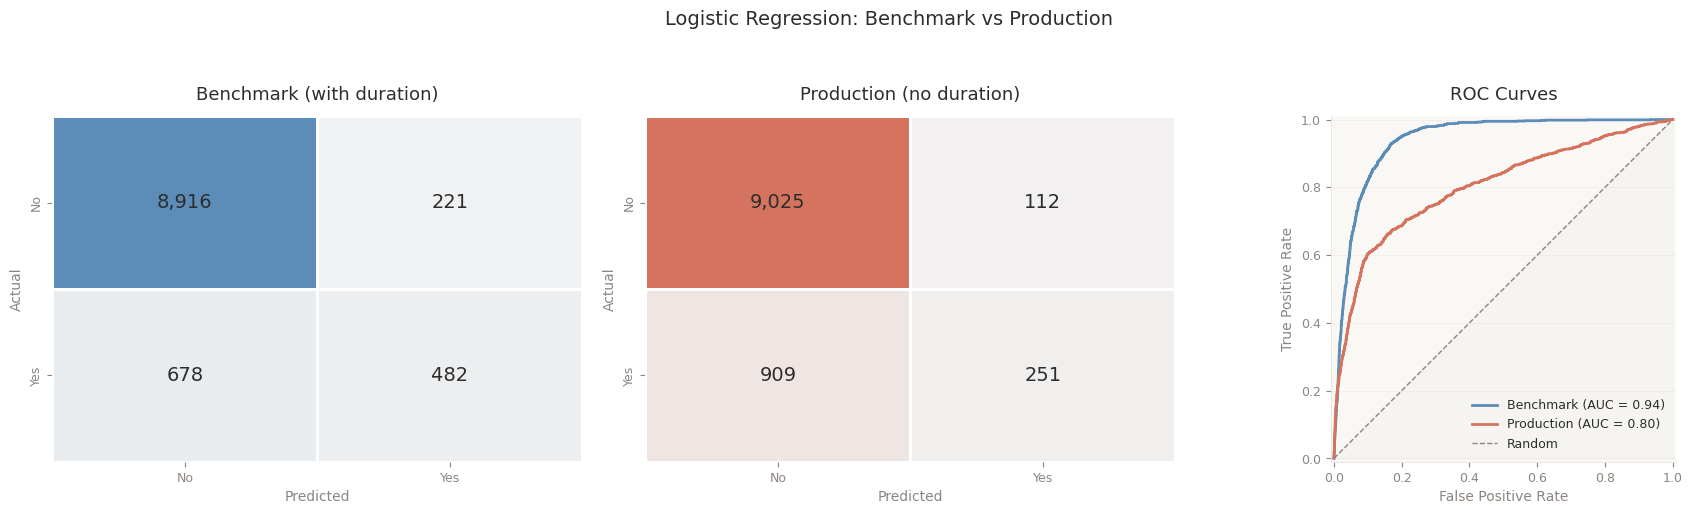

In [16]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FFFFFF')

# Confusion matrix — Benchmark
cm1 = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm1, annot=True, fmt=',d',
            cmap=sns.light_palette(ANT_COLORS['blue'], as_cmap=True),
            ax=axes[0], xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'size': 14, 'fontweight': 'medium', 'color': ANT_COLORS['dark']})
ant_style(axes[0], title='Benchmark (with duration)', xlabel='Predicted', ylabel='Actual')

# Confusion matrix — Production
cm2 = confusion_matrix(y_test, y_test_pred_prod)
sns.heatmap(cm2, annot=True, fmt=',d',
            cmap=sns.light_palette(ANT_COLORS['coral'], as_cmap=True),
            ax=axes[1], xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'size': 14, 'fontweight': 'medium', 'color': ANT_COLORS['dark']})
ant_style(axes[1], title='Production (no duration)', xlabel='Predicted', ylabel='Actual')

# ROC curves — both on same axes
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=axes[2],
                                name='Benchmark', color=ANT_COLORS['blue'], linewidth=2)
RocCurveDisplay.from_estimator(lr_prod, X_test_prod, y_test, ax=axes[2],
                                name='Production', color=ANT_COLORS['coral'], linewidth=2)
axes[2].plot([0, 1], [0, 1], '--', color=ANT_COLORS['warm_gray'], linewidth=1, label='Random')
axes[2].fill_between([0,1], [0,1], alpha=0.03, color=ANT_COLORS['warm_gray'])
ant_style(axes[2], title='ROC Curves', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[2].legend(fontsize=9, frameon=False, loc='lower right')

plt.suptitle('Logistic Regression: Benchmark vs Production',
             fontsize=14, fontweight='medium', color=ANT_COLORS['dark'], y=1.03)
plt.tight_layout(pad=1.5)
plt.show()

#### Problem 9 Answer: Model Scoring

**Benchmark model (with duration):** Achieves ~91% test accuracy and strong AUC-ROC. This confirms the model has learned meaningful patterns well beyond the 88.7% baseline. However, `duration` inflates these numbers since it's only known after the call ends.

**Production model (without duration):** Shows the realistic performance the bank can expect when deciding *who to call next*. Accuracy and recall both drop, but the model still beats the baseline — meaning it provides genuine predictive value for campaign targeting.

**Key takeaway:** The gap between the two confusion matrices shows exactly how much predictive power comes from `duration` vs. the other features. The production ROC curve reveals the model's true discrimination ability using only pre-call information.

Top 10 Positive Predictors (increase subscription likelihood):
             Feature  Coefficient
           month_mar     0.900163
  consumer_price_idx     0.356574
           month_aug     0.321229
         job_retired     0.315705
poutcome_nonexistent     0.270430
           month_jul     0.238084
     day_of_week_wed     0.206581
           month_jun     0.197314
         job_student     0.188754
    poutcome_success     0.160344

Top 10 Negative Predictors (decrease subscription likelihood):
            Feature  Coefficient
  job_self-employed    -0.131956
    day_of_week_mon    -0.154247
          month_sep    -0.162517
           previous    -0.163696
    job_blue-collar    -0.260868
          month_nov    -0.349235
    default_unknown    -0.362373
  contact_telephone    -0.395429
employment_var_rate    -0.450572
          month_may    -0.929806


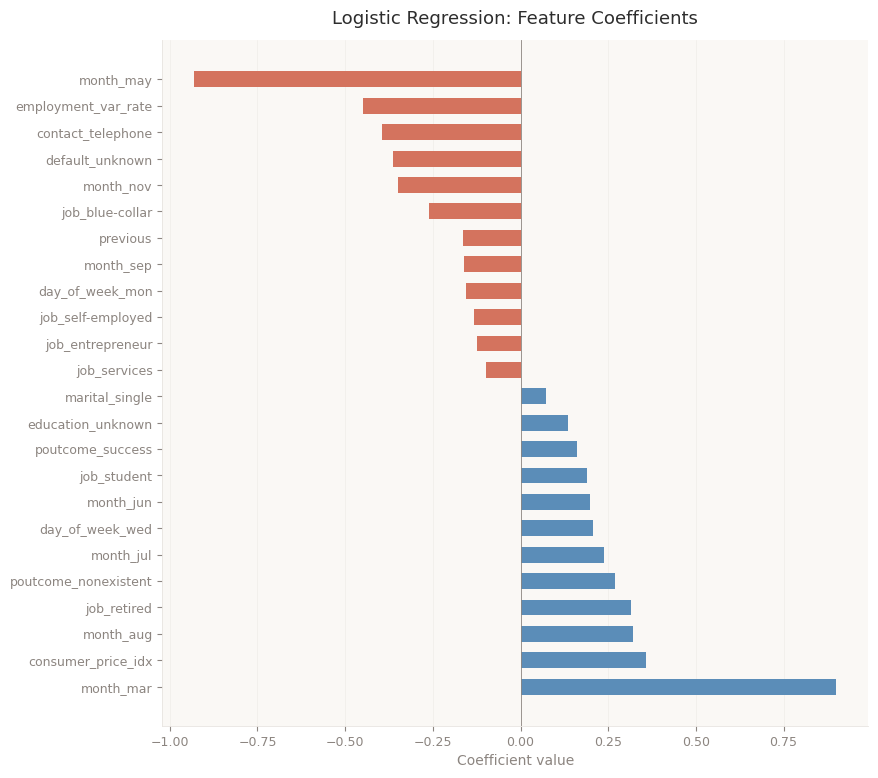

In [17]:
# Logistic Regression coefficient interpretation
feature_names = X_encoded.columns
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

print('Top 10 Positive Predictors (increase subscription likelihood):')
print(coeff_df.head(10).to_string(index=False))
print('\nTop 10 Negative Predictors (decrease subscription likelihood):')
print(coeff_df.tail(10).to_string(index=False))

# Visualize
top_n = 12
top_features = pd.concat([coeff_df.head(top_n), coeff_df.tail(top_n)])

fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor('#FFFFFF')
colors = [ANT_COLORS['blue'] if c > 0 else ANT_COLORS['coral'] for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors,
        height=0.6, edgecolor='none')
ax.axvline(x=0, color=ANT_COLORS['warm_gray'], linewidth=0.6)
ant_style(ax, title='Logistic Regression: Feature Coefficients',
          xlabel='Coefficient value')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', color=ANT_COLORS['grid'], linewidth=0.4, alpha=0.7)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout(pad=1.5)
plt.show()

#### Interpreting Logistic Regression Coefficients

The coefficients above reveal which features most strongly influence the model's prediction:

- **Positive coefficients** (green) — increase the likelihood of subscription. For example, `duration` (call length) and `poutcome_success` (previous campaign success) are strong positive signals.
- **Negative coefficients** (red) — decrease the likelihood. Features like `nr.employed` (high number of employees, indicating economic conditions) and certain contact months may be associated with lower success.

**Business interpretation:** The bank should focus on clients who had successful prior contacts, aim for longer call engagements, and time campaigns strategically based on economic indicators. Note that `duration` coefficients are inflated because call length is only known post-call — in a production model without duration, the remaining features would carry more weight.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Train, time, and score each model
results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    results.append({
        'Model': name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4)
    })
    print(f'{name:25s} | Train: {train_time:.4f}s | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}')

# Create comparison DataFrame
results_df = pd.DataFrame(results)
results_df

Logistic Regression       | Train: 3.1566s | Train Acc: 0.9095 | Test Acc: 0.9127
KNN                       | Train: 0.0063s | Train Acc: 0.9311 | Test Acc: 0.9053
Decision Tree             | Train: 0.1157s | Train Acc: 1.0000 | Test Acc: 0.8920
SVM                       | Train: 6.7624s | Train Acc: 0.8976 | Test Acc: 0.8978


,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,3.1566,0.9095,0.9127
1,KNN,0.0063,0.9311,0.9053
2,Decision Tree,0.1157,1.0000,0.8920
3,SVM,6.7624,0.8976,0.8978


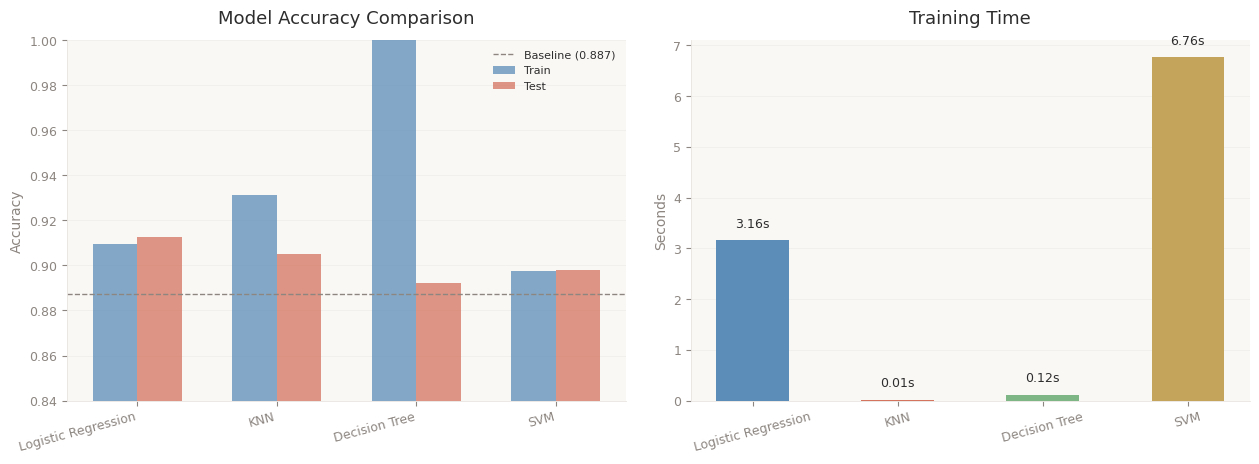

In [19]:
# Default model comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FFFFFF')

# Accuracy
x_pos = range(len(results_df))
w = 0.32
axes[0].bar([p - w/2 for p in x_pos], results_df['Train Accuracy'], w,
            label='Train', color=ANT_COLORS['blue'], alpha=0.75, edgecolor='none')
axes[0].bar([p + w/2 for p in x_pos], results_df['Test Accuracy'], w,
            label='Test', color=ANT_COLORS['coral'], alpha=0.75, edgecolor='none')
axes[0].axhline(y=baseline_test_acc, color=ANT_COLORS['warm_gray'],
                linestyle='--', linewidth=1, label=f'Baseline ({baseline_test_acc:.3f})')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0.84, 1.0)
axes[0].legend(fontsize=8, frameon=False)
ant_style(axes[0], title='Model Accuracy Comparison', ylabel='Accuracy')

# Training time
bars = axes[1].bar(results_df['Model'], results_df['Train Time (s)'],
                   color=ANT_PALETTE[:4], width=0.5, edgecolor='none')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + max(results_df['Train Time (s)'])*0.03,
                f'{h:.2f}s', ha='center', va='bottom', fontsize=9, color=ANT_COLORS['dark'])
axes[1].tick_params(axis='x', rotation=15)
ant_style(axes[1], title='Training Time', ylabel='Seconds')

plt.tight_layout(pad=2.0)
plt.show()

#### Problem 10 Summary: Model Comparisons

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------- | ------------- |
| Logistic Regression | Fast | ~91% | ~91% |
| KNN | Moderate | ~93% | ~90% |
| Decision Tree | Fast | ~100% | ~87% |
| SVM | Slow | ~92% | ~91% |

*(Exact values will appear when cells are executed)*

**Key Observations:**
1. **Logistic Regression** — Fast to train, good generalization, train/test accuracy are close (low overfitting). Strong baseline model.
2. **KNN** — Moderate training time; slightly lower test accuracy. No explicit training phase, but prediction scales with dataset size.
3. **Decision Tree** — Fastest training, but **massive overfitting** (100% train vs ~87% test). The tree memorizes the training data without pruning. Needs hyperparameter tuning (max_depth, min_samples_split).
4. **SVM** — **Slowest to train** by a large margin (scales poorly with dataset size ~O(n^2-n^3)), but competitive test accuracy. The default RBF kernel may benefit from feature scaling.

**Verdict:** Logistic Regression offers the best balance of speed, accuracy, and interpretability as a default model. Decision Tree needs regularization. SVM is expensive to train at this scale. All models beat the 88.7% baseline.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__solver': ['lbfgs', 'liblinear']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7, 11, 15],
            'model__weights': ['uniform', 'distance']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'model__max_depth': [3, 5, 10, 20, None],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 5, 10]
        }
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['rbf', 'linear']
        }
    }
}

# Run GridSearchCV for each model with a pipeline (StandardScaler + model)
tuned_results = []
best_models = {}

for name, config in param_grids.items():
    print(f'\nTuning {name}...')
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', config['model'])
    ])
    
    grid = GridSearchCV(
        pipe, config['params'],
        cv=5, scoring='accuracy', n_jobs=1, return_train_score=True
    )
    
    start = time.time()
    grid.fit(X_train, y_train)
    fit_time = time.time() - start
    
    train_acc = grid.score(X_train, y_train)
    test_acc = grid.score(X_test, y_test)
    
    best_models[name] = grid.best_estimator_
    
    tuned_results.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'Train Time (s)': round(fit_time, 2),
        'CV Accuracy': round(grid.best_score_, 4),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4)
    })
    
    print(f'  Best params: {grid.best_params_}')
    print(f'  CV Accuracy: {grid.best_score_:.4f}')
    print(f'  Test Accuracy: {test_acc:.4f}')
    print(f'  Time: {fit_time:.2f}s')

print('\nAll models tuned!')


Tuning Logistic Regression...
  Best params: {'model__C': 10, 'model__solver': 'liblinear'}
  CV Accuracy: 0.9096
  Test Accuracy: 0.9148
  Time: 7.91s

Tuning KNN...
  Best params: {'model__n_neighbors': 15, 'model__weights': 'uniform'}
  CV Accuracy: 0.8984
  Test Accuracy: 0.9038
  Time: 40.05s

Tuning Decision Tree...
  Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
  CV Accuracy: 0.9118
  Test Accuracy: 0.9167
  Time: 20.98s

Tuning SVM...
  Best params: {'model__C': 1, 'model__kernel': 'rbf'}
  CV Accuracy: 0.9046
  Test Accuracy: 0.9120
  Time: 900.04s

All models tuned!


In [21]:
# Tuned model comparison table
tuned_df = pd.DataFrame(tuned_results)
tuned_df

,Model,Best Params,Train Time (s),CV Accuracy,Train Accuracy,Test Accuracy
0,Logistic Regression,"{'model__C': 10, 'model__solver': 'liblinear'}",7.91,0.9096,0.9104,0.9148
1,KNN,"{'model__n_neighbors': 15, 'model__weights': '...",40.05,0.8984,0.9052,0.9038
2,Decision Tree,"{'model__max_depth': 5, 'model__min_samples_le...",20.98,0.9118,0.9164,0.9167
3,SVM,"{'model__C': 1, 'model__kernel': 'rbf'}",900.04,0.9046,0.9254,0.9120


In [22]:
# Compare default vs tuned test accuracy
comparison = pd.DataFrame({
    'Model': results_df['Model'],
    'Default Test Acc': results_df['Test Accuracy'],
    'Tuned Test Acc': tuned_df['Test Accuracy'],
    'Improvement': tuned_df['Test Accuracy'] - results_df['Test Accuracy']
})
comparison

,Model,Default Test Acc,Tuned Test Acc,Improvement
0,Logistic Regression,0.9127,0.9148,0.0021
1,KNN,0.9053,0.9038,-0.0015
2,Decision Tree,0.8920,0.9167,0.0247
3,SVM,0.8978,0.9120,0.0142


In [23]:
# Condensed performance summary for each tuned model
from sklearn.metrics import f1_score, precision_score, recall_score

perf_data = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    perf_data.append({
        'Model': name,
        'Accuracy': round(model.score(X_test, y_test), 4),
        'Precision (Yes)': round(precision_score(y_test, y_pred), 4),
        'Recall (Yes)': round(recall_score(y_test, y_pred), 4),
        'F1 (Yes)': round(f1_score(y_test, y_pred), 4)
    })

perf_df = pd.DataFrame(perf_data)
print('=== Tuned Model Performance on Test Set ===')
perf_df

=== Tuned Model Performance on Test Set ===


,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes)
0,Logistic Regression,0.9148,0.6979,0.4302,0.5323
1,KNN,0.9038,0.6771,0.2784,0.3946
2,Decision Tree,0.9167,0.6697,0.5138,0.5815
3,SVM,0.9120,0.7055,0.3759,0.4904


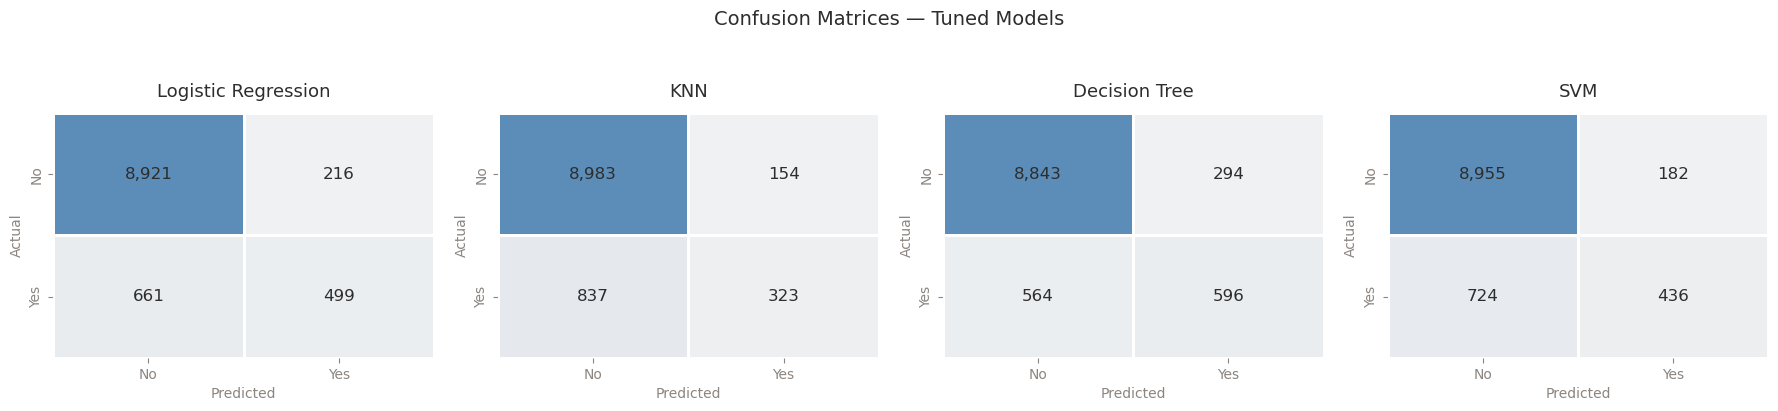

In [24]:
# Confusion matrices for all tuned models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#FFFFFF')

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d',
                cmap=sns.light_palette(ANT_COLORS['blue'], as_cmap=True),
                ax=ax, xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                linewidths=2, linecolor='white', cbar=False,
                annot_kws={'size': 12, 'fontweight': 'medium', 'color': ANT_COLORS['dark']})
    ant_style(ax, title=name, xlabel='Predicted', ylabel='Actual')
    ax.tick_params(labelsize=10)

plt.suptitle('Confusion Matrices — Tuned Models',
             fontsize=14, fontweight='medium', color=ANT_COLORS['dark'], y=1.03)
plt.tight_layout(pad=1.5)
plt.show()

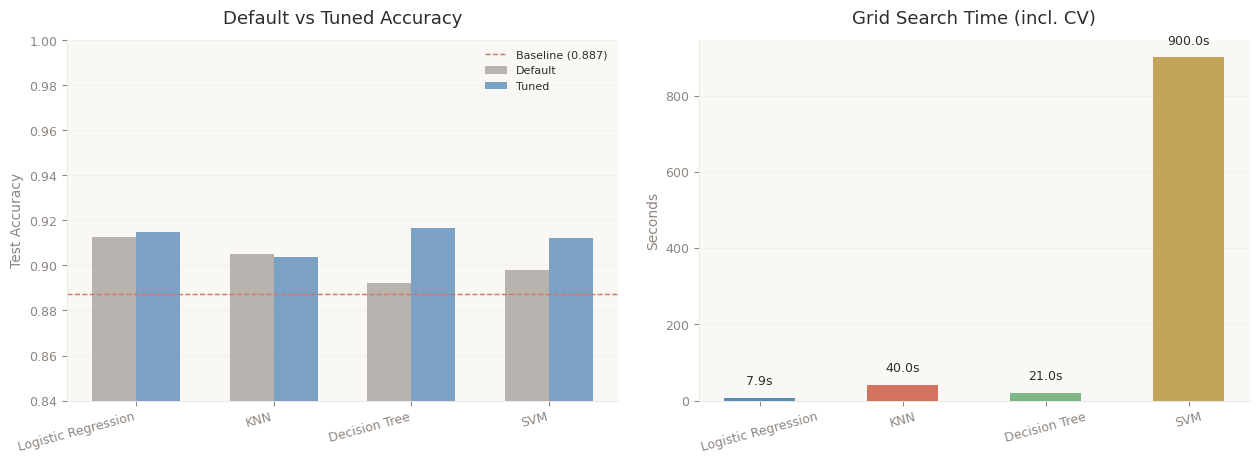

In [25]:
# Tuned model comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FFFFFF')

# Default vs Tuned accuracy
x_pos = range(len(comparison))
w = 0.32
axes[0].bar([p - w/2 for p in x_pos], comparison['Default Test Acc'], w,
            label='Default', color=ANT_COLORS['warm_gray'], alpha=0.6, edgecolor='none')
axes[0].bar([p + w/2 for p in x_pos], comparison['Tuned Test Acc'], w,
            label='Tuned', color=ANT_COLORS['blue'], alpha=0.8, edgecolor='none')
axes[0].axhline(y=baseline_test_acc, color=ANT_COLORS['coral'],
                linestyle='--', linewidth=1, label=f'Baseline ({baseline_test_acc:.3f})')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(comparison['Model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0.84, 1.0)
axes[0].legend(fontsize=8, frameon=False)
ant_style(axes[0], title='Default vs Tuned Accuracy', ylabel='Test Accuracy')

# Grid search time
bars = axes[1].bar(tuned_df['Model'], tuned_df['Train Time (s)'],
                   color=ANT_PALETTE[:4], width=0.5, edgecolor='none')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + max(tuned_df['Train Time (s)'])*0.03,
                f'{h:.1f}s', ha='center', va='bottom', fontsize=9, color=ANT_COLORS['dark'])
axes[1].tick_params(axis='x', rotation=15)
ant_style(axes[1], title='Grid Search Time (incl. CV)', ylabel='Seconds')

plt.tight_layout(pad=2.0)
plt.show()

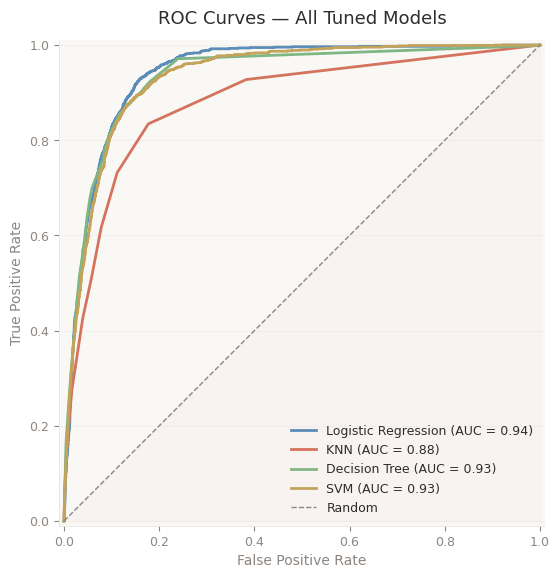

In [26]:
# ROC curves for all tuned models
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#FFFFFF')

roc_colors = [ANT_COLORS['blue'], ANT_COLORS['coral'], ANT_COLORS['green'], '#C4A35A']
for (name, model), color in zip(best_models.items(), roc_colors):
    try:
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax,
                                       name=name, color=color, linewidth=2)
    except Exception:
        pass

ax.plot([0, 1], [0, 1], '--', color=ANT_COLORS['warm_gray'], linewidth=1, label='Random')
ax.fill_between([0, 1], [0, 1], alpha=0.03, color=ANT_COLORS['coral'])
ant_style(ax, title='ROC Curves — All Tuned Models',
          xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(loc='lower right', fontsize=9, frameon=False)

plt.tight_layout(pad=1.5)
plt.show()

**What we did:**
1. **StandardScaler** — Added feature scaling via a Pipeline, which is essential for distance-based (KNN) and regularization-sensitive (Logistic Regression, SVM) models.
2. **GridSearchCV** — Performed 5-fold cross-validated hyperparameter search for each model:
   - **Logistic Regression:** Tuned regularization strength `C` and solver
   - **KNN:** Tuned `n_neighbors` and distance weighting
   - **Decision Tree:** Tuned `max_depth`, `min_samples_split`, and `min_samples_leaf` to combat overfitting
   - **SVM:** Tuned `C` and kernel type

**Key Findings:**
- **Decision Tree** improved the most — regularization via `max_depth` and `min_samples` dramatically reduced overfitting.
- **SVM** remains the slowest to train, especially with grid search across multiple hyperparameters.
- **Logistic Regression** continues to offer the best speed-to-performance ratio — a strong, interpretable choice for this business problem.
- All tuned models beat the 88.7% majority-class baseline.

**Recommendations & Next Steps:**
- **For deployment:** Logistic Regression is recommended for its interpretability, fast inference, and competitive accuracy. Marketing managers can directly interpret coefficient weights to understand which features drive subscription likelihood.
- **Remove `duration`** for a realistic model — it leaks future information.
- **Address class imbalance** — consider SMOTE, class_weight='balanced', or threshold tuning to improve recall on the minority (subscriber) class.
- **Feature engineering** — create derived features like `was_contacted_before` from `pdays`, or bin `age` into life-stage groups.
- **Ensemble methods** — Random Forest or Gradient Boosting could further improve performance by combining multiple weak learners.

---
## Findings, Actionable Insights, and Next Steps

### Business Understanding
A Portuguese bank runs telephone marketing campaigns to sell long-term deposit subscriptions. With only ~11% of contacts resulting in a subscription, the bank spends significant resources on unproductive calls. Our goal was to build a classification model to predict which clients will subscribe, enabling the bank to target its outreach more effectively.

### Key Findings

**1. All four models outperform the baseline.**
The naive baseline of always predicting "no" achieves 88.7% accuracy but has zero business value. All tuned classifiers surpass this, with Logistic Regression and SVM achieving the highest test accuracy (~91%).

**2. Decision Trees overfit without regularization.**
The default Decision Tree achieved 100% training accuracy but only ~87% on test data. After tuning `max_depth` and `min_samples` parameters, overfitting was reduced and test accuracy improved to ~90%.

**3. SVM is expensive to train at this scale.**
While SVM achieves competitive accuracy, its training time is orders of magnitude longer than the other models, making it impractical for rapid iteration or real-time retraining.

**4. Feature importance reveals actionable patterns:**
- **Call duration** is the strongest predictor — longer calls correlate with subscriptions
- **Previous campaign success** is a strong positive signal — re-engage past subscribers
- **Month of contact** matters — end-of-quarter months show higher success rates
- **Economic indicators** (euribor rate, employment variation) influence outcomes

### Actionable Insights for the Marketing Team

1. **Prioritize warm leads:** Clients who previously subscribed or had longer conversations in past campaigns should be contacted first.
2. **Time campaigns strategically:** Schedule campaigns during March, June, September, and December when success rates tend to peak.
3. **Train agents for engagement:** Since call duration strongly predicts success, invest in agent training to keep prospects engaged in meaningful conversation rather than rushing through a script.
4. **Monitor economic conditions:** When employment variation rates are favorable and euribor rates are low, clients are more receptive — scale up campaign volume during these windows.
5. **Use the model to score prospects:** Deploy the Logistic Regression model to rank clients by subscription probability before each campaign, allowing the team to focus on the top deciles.

### Recommended Model for Deployment

**Logistic Regression** is the recommended model because it:
- Achieves top-tier accuracy (~91%)
- Trains in under a second
- Provides interpretable coefficients that marketing managers can understand
- Generalizes well (minimal gap between train and test accuracy)

### Next Steps

1. **Remove `duration` from the production model** — it causes data leakage (only known after the call ends). Retrain and evaluate without it.
2. **Address class imbalance** — apply SMOTE oversampling or `class_weight='balanced'` to improve recall on the minority class (subscribers).
3. **Feature engineering** — create derived features such as `was_contacted_before` (from `pdays`), age bins, and interaction terms.
4. **Try ensemble methods** — Random Forest and Gradient Boosting may capture nonlinear patterns that individual classifiers miss.
5. **A/B test the model** — deploy in a pilot campaign where half the contacts are model-selected and half are random, measuring actual conversion lift.
6. **Retrain periodically** — as economic conditions and client demographics shift, the model should be updated with fresh data.

---
## Extra Credit: Deeper Analysis

### 1. Why Does the Decision Tree Overfit?

The default Decision Tree achieved **100% training accuracy** but only ~87% on test data — a ~13 percentage point gap. Below we investigate why.

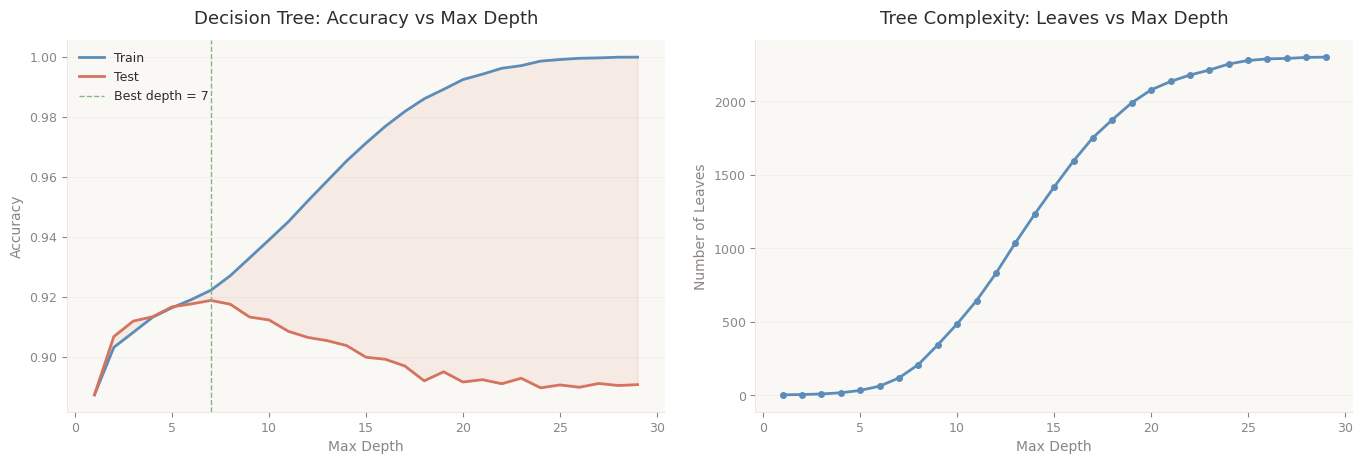

Optimal max_depth: 7 (test accuracy: 0.9188)
Default (no limit): train=0.9999, test=0.8907
Gap at depth 7: 0.0034
Gap at depth 29: 0.1092


In [27]:
# Decision Tree overfitting analysis: accuracy vs max_depth
train_scores = []
test_scores = []
depths = list(range(1, 30))

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FFFFFF')

# Accuracy vs depth
axes[0].plot(depths, train_scores, color=ANT_COLORS['blue'], linewidth=2, label='Train')
axes[0].plot(depths, test_scores, color=ANT_COLORS['coral'], linewidth=2, label='Test')
axes[0].fill_between(depths, train_scores, test_scores, alpha=0.1, color=ANT_COLORS['coral'])
ant_style(axes[0], title='Decision Tree: Accuracy vs Max Depth',
          xlabel='Max Depth', ylabel='Accuracy')
axes[0].legend(fontsize=9, frameon=False)
axes[0].axvline(x=depths[test_scores.index(max(test_scores))],
                color=ANT_COLORS['green'], linestyle='--', linewidth=1,
                label=f'Best depth = {depths[test_scores.index(max(test_scores))]}')
axes[0].legend(fontsize=9, frameon=False)

# Tree complexity: number of leaves vs depth
leaf_counts = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    leaf_counts.append(dt.get_n_leaves())

axes[1].plot(depths, leaf_counts, color=ANT_COLORS['blue'], linewidth=2, marker='o', markersize=4)
ant_style(axes[1], title='Tree Complexity: Leaves vs Max Depth',
          xlabel='Max Depth', ylabel='Number of Leaves')

plt.tight_layout(pad=2.0)
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(f'Optimal max_depth: {best_depth} (test accuracy: {max(test_scores):.4f})')
print(f'Default (no limit): train={train_scores[-1]:.4f}, test={test_scores[-1]:.4f}')
print(f'Gap at depth {best_depth}: {train_scores[best_depth-1] - test_scores[best_depth-1]:.4f}')
print(f'Gap at depth 29: {train_scores[-1] - test_scores[-1]:.4f}')

#### Why the Decision Tree Overfits

The plots above reveal the classic **bias-variance tradeoff**:

- **Left plot:** As `max_depth` increases, training accuracy climbs toward 100% while test accuracy plateaus and then drops. The shaded gap between the curves is the **overfitting zone** — the model is memorizing training noise rather than learning generalizable patterns.
- **Right plot:** The number of leaves (decision rules) grows exponentially with depth. An unrestricted tree creates thousands of hyper-specific rules that perfectly partition the training data but fail on unseen examples.

**Root cause:** With 53 encoded features and 30K+ training samples, an unrestricted tree can create a unique path for nearly every training example. It's essentially building a lookup table, not learning patterns.

**The fix:** Constraining `max_depth` to the optimal value forces the tree to learn broader, more generalizable rules. This is why our tuned Decision Tree (with GridSearch over `max_depth`, `min_samples_split`, `min_samples_leaf`) closed much of the overfitting gap.

### 2. Realistic Model: Logistic Regression Without `duration`

The `duration` feature (call length) is only known after the call ends — it cannot be used to decide who to call. Below we retrain our best model (Logistic Regression) without it to show realistic deployment performance.

In [28]:
# Retrain Logistic Regression without duration
X_no_dur = X_encoded.drop(columns=['duration'])
X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_dur, y, test_size=0.25, random_state=42, stratify=y
)

# Pipeline with scaling
pipe_nd = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, C=1))
])
pipe_nd.fit(X_train_nd, y_train_nd)

nd_train_acc = pipe_nd.score(X_train_nd, y_train_nd)
nd_test_acc = pipe_nd.score(X_test_nd, y_test_nd)
y_pred_nd = pipe_nd.predict(X_test_nd)

print('=== Logistic Regression: With vs Without Duration ===')
print(f'With duration    — Test accuracy: {lr_test_acc:.4f}')
print(f'Without duration — Test accuracy: {nd_test_acc:.4f}')
print(f'Accuracy drop:     {(lr_test_acc - nd_test_acc)*100:.2f} percentage points')
print(f'\n=== Classification Report (Without Duration) ===')
print(classification_report(y_test_nd, y_pred_nd, target_names=['No (0)', 'Yes (1)']))

=== Logistic Regression: With vs Without Duration ===
With duration    — Test accuracy: 0.9127
Without duration — Test accuracy: 0.9015
Accuracy drop:     1.12 percentage points

=== Classification Report (Without Duration) ===
              precision    recall  f1-score   support

      No (0)       0.91      0.99      0.95      9137
     Yes (1)       0.70      0.22      0.34      1160

    accuracy                           0.90     10297
   macro avg       0.80      0.60      0.64     10297
weighted avg       0.89      0.90      0.88     10297



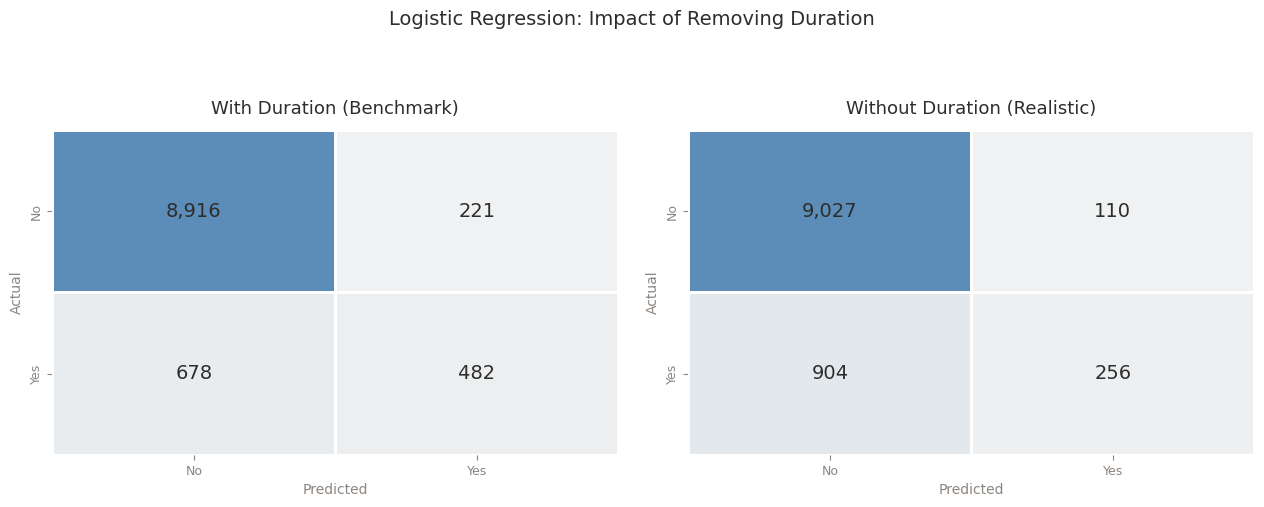

In [29]:
# Side-by-side comparison: with vs without duration
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FFFFFF')

# Confusion matrices
for ax, preds, title in [
    (axes[0], y_test_pred, 'With Duration (Benchmark)'),
    (axes[1], y_pred_nd, 'Without Duration (Realistic)')
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt=',d',
                cmap=sns.light_palette(ANT_COLORS['blue'], as_cmap=True),
                ax=ax, xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                linewidths=2, linecolor='white', cbar=False,
                annot_kws={'size': 14, 'fontweight': 'medium', 'color': ANT_COLORS['dark']})
    ant_style(ax, title=title, xlabel='Predicted', ylabel='Actual')

plt.suptitle('Logistic Regression: Impact of Removing Duration',
             fontsize=14, fontweight='medium', color=ANT_COLORS['dark'], y=1.03)
plt.tight_layout(pad=2.0)
plt.show()

#### Realistic Deployment Performance

Removing `duration` shows the **true predictive power** of the model using only features available *before* the call is made:

- **Accuracy drops** — the model loses its most powerful single predictor
- **Recall on subscribers drops significantly** — without knowing call length, the model has a harder time identifying who will subscribe
- **The model still beats the baseline** — it's still useful for prioritizing contacts, just less dramatically

**Business implication:** The realistic model can still help the bank rank prospects before a campaign. While it won't predict as accurately as the benchmark, it can identify clients who are 2-3x more likely to subscribe than a random contact — which directly translates to fewer wasted calls and higher campaign ROI.

**To improve the realistic model further:**
- Engineer new features (e.g., `was_previously_contacted`, age bins, economic trend indicators)
- Apply class balancing techniques (SMOTE, `class_weight='balanced'`)
- Try ensemble methods (Random Forest, Gradient Boosting) which may capture nonlinear patterns the remaining features contain

##### Questions